# Sensitivity Analysis: Two-Species Competition-Diffusion Model with Harvesting

**Module:** Computational Modelling 2 | **Date:** March 2026

This notebook carries out a local one-at-a-time sensitivity analysis for the 1D two-species competition-diffusion-harvesting PDE model from `02_1d_pde.ipynb`. Each baseline parameter is perturbed by +/-10% while all others are held fixed, and the resulting change in equilibrium mean density is recorded.

**Contents**

1. Mathematical Model
2. Baseline Parameters
3. Baseline Simulation
4. Local Sensitivity Analysis
5. Results Table
6. Tornado Plot
7. Time-Series Comparison (Top 3 Sensitive Parameters)
8. Fixed-Time Response (Top 3 Sensitive Parameters)
9. Parameter Sweep Analysis ($r_1$, $\alpha_{12}$, $H_1$)
10. Discussion and Summary

## 1. Mathematical Model

The model is a 1D two-species reaction-diffusion PDE system on the domain $s \in [0, L]$ with no-flux (Neumann) boundary conditions:

$$\frac{\partial N_1}{\partial t} = D_1 \frac{\partial^2 N_1}{\partial s^2} + r_1 N_1 \left(1 - \frac{N_1 + \alpha_{12}\, N_2}{K_1}\right) - H_1 N_1$$

$$\frac{\partial N_2}{\partial t} = D_2 \frac{\partial^2 N_2}{\partial s^2} + r_2 N_2 \left(1 - \frac{N_2 + \alpha_{21}\, N_1}{K_2}\right) - H_2 N_2$$

| Symbol | Meaning | Units |
|--------|---------|-------|
| $N_1, N_2$ | Population densities of species 1 and 2 | - |
| $r_1, r_2$ | Intrinsic growth rates | yr$^{-1}$ |
| $K_1, K_2$ | Carrying capacities | - |
| $\alpha_{12}$ | Competition effect of species 2 on species 1 | - |
| $\alpha_{21}$ | Competition effect of species 1 on species 2 | - |
| $D_1, D_2$ | Diffusion coefficients | miles$^2$ yr$^{-1}$ |
| $H_1, H_2$ | Uniform harvesting rates | yr$^{-1}$ |

**Numerical scheme:** Explicit forward-Euler time stepping with ghost-point Neumann boundary conditions. The time step $\Delta t$ is chosen adaptively to satisfy both the diffusion CFL limit and the reaction stability bound.

In [101]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

sys.path.insert(0, '.')
from pde_solver import simulate_competing_rd_fishing
from plotting import plot_biomass_2s

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print('Imports successful.')

Imports successful.


## 2. Baseline Parameters

Baseline values are taken from the two-species EEZ case in `02_1d_pde.ipynb` (Section 4C). In this notebook, harvesting is applied uniformly across the full domain at rate $H_i$, so the test problem removes spatial variation in fishing pressure and isolates parameter effects more cleanly.

The simulation runs to $T_{\rm end} = 100$ years, well beyond the characteristic logistic timescale $1/r \approx 2$ yr, so the solution reaches its spatial equilibrium.

In [102]:
# Baseline parameter dictionary
BASE = dict(
    L     = 600.0,   # domain length (miles)
    N     = 301,     # spatial grid points
    D1    = 10.0,    # diffusion coeff. sp.1 (miles^2 yr^-1)
    D2    = 10.0,    # diffusion coeff. sp.2
    r1    = 0.5,     # intrinsic growth rate sp.1 (yr^-1)
    r2    = 0.5,     # intrinsic growth rate sp.2
    K1    = 1.0,     # carrying capacity sp.1
    K2    = 1.0,     # carrying capacity sp.2
    alpha = 0.5,     # alpha_12: competition effect of sp.2 on sp.1
    beta  = 0.5,     # alpha_21: competition effect of sp.1 on sp.2
    H1    = 0.1,     # harvesting rate sp.1 (yr^-1)
    H2    = 0.1,     # harvesting rate sp.2
)

T_END = 100.0              # simulation end time (years)
PERTURB = 0.10             # +/-10% perturbation factor
FIXED_TIME = 100.0         # fixed time for dense local sweeps (years)
FIXED_SWEEP_POINTS = 9     # number of samples across the +/-10% interval

# Pretty-print table
param_meta = [
    ('r1',    'Intrinsic growth rate sp.1',   BASE['r1'],    'yr^-1'),
    ('r2',    'Intrinsic growth rate sp.2',   BASE['r2'],    'yr^-1'),
    ('K1',    'Carrying capacity sp.1',       BASE['K1'],    '-'),
    ('K2',    'Carrying capacity sp.2',       BASE['K2'],    '-'),
    ('alpha', 'Competition coeff alpha_12',   BASE['alpha'], '-'),
    ('beta',  'Competition coeff alpha_21',   BASE['beta'],  '-'),
    ('D1',    'Diffusion coeff sp.1',         BASE['D1'],    'miles^2 yr^-1'),
    ('D2',    'Diffusion coeff sp.2',         BASE['D2'],    'miles^2 yr^-1'),
    ('H1',    'Harvesting rate sp.1',         BASE['H1'],    'yr^-1'),
    ('H2',    'Harvesting rate sp.2',         BASE['H2'],    'yr^-1'),
]
df_baseline = pd.DataFrame(param_meta,
                           columns=['Symbol', 'Description', 'Baseline value', 'Units'])
display(df_baseline.style.hide(axis='index'))

Symbol,Description,Baseline value,Units
r1,Intrinsic growth rate sp.1,0.500000,yr^-1
r2,Intrinsic growth rate sp.2,0.500000,yr^-1
K1,Carrying capacity sp.1,1.000000,-
K2,Carrying capacity sp.2,1.000000,-
alpha,Competition coeff alpha_12,0.500000,-
beta,Competition coeff alpha_21,0.500000,-
D1,Diffusion coeff sp.1,10.000000,miles^2 yr^-1
D2,Diffusion coeff sp.2,10.000000,miles^2 yr^-1
H1,Harvesting rate sp.1,0.100000,yr^-1
H2,Harvesting rate sp.2,0.100000,yr^-1


In [103]:
def run_model(p, T_end=None, snap_times=None):
    """Simulate the two-species PDE and return (eq_N1, eq_N2, result_dict).

    Equilibrium densities are the spatial-mean concentrations at T_end:
        eq_Ni = B_i_tot(T_end) / L
    where B_i_tot is the trapezoid integral of Ni over [0, L].

    Uniform harvesting is applied (h_in = h_out = H) so both sides of the
    EEZ boundary experience the same fishing pressure.
    """
    if T_end is None:
        T_end = T_END
    if snap_times is None:
        snap_times = [T_end]

    res = simulate_competing_rd_fishing(
        L=p['L'],  N=p['N'],
        D1=p['D1'], D2=p['D2'],
        r1=p['r1'], r2=p['r2'],
        K1=p['K1'], K2=p['K2'],
        alpha=p['alpha'], beta=p['beta'],
        T_end=T_end,
        h1_in=p['H1'], h1_out=p['H1'],
        h2_in=p['H2'], h2_out=p['H2'],
        snapshot_times=snap_times,
    )

    # Spatial-mean density at final time = total biomass / domain length
    eq_N1 = res['B1_tot'][-1] / p['L']
    eq_N2 = res['B2_tot'][-1] / p['L']
    return eq_N1, eq_N2, res


print('run_model() ready.')

run_model() ready.


## 3. Baseline Simulation

Run the model with all baseline parameters. Spatial snapshots are recorded at $t = 0, 25, 50, 75, 100$ yr to show both the transient dynamics and the long-run equilibrium.

The equilibrium density $N_i^*$ is defined as the domain-averaged population at $t = T_{\rm end}$:

$$N_i^* = \frac{1}{L} \int_0^L N_i(s,\, T_{\rm end})\, \mathrm{d}s$$

In [104]:
SNAP_TIMES = [0.0, 25.0, 50.0, 75.0, T_END]

print('Running baseline simulation ...')
eq_N1_base, eq_N2_base, res_base = run_model(BASE, snap_times=SNAP_TIMES)

print(f'\nBaseline results  (T = {T_END:.0f} yr)')
print(f'  N1* = {eq_N1_base:.5f}   (mean density across domain)')
print(f'  N2* = {eq_N2_base:.5f}')
print(f'  dt  = {res_base["dt"]:.4f} yr   |   nt = {res_base["nt"]:,} steps')
print()
# Analytical check: uniform PDE without diffusion/competition -> N* = K(1 - H/r)
N_analytical = BASE['K1'] * (1 - BASE['H1'] / BASE['r1'])
print(f'  Analytical check (no competition, no diffusion):  N* = K(1 - H/r) = {N_analytical:.3f}')
print('  (Simulated values are lower due to interspecific competition)')

Running baseline simulation ...

Baseline results  (T = 100 yr)
  N1* = 0.46676   (mean density across domain)
  N2* = 0.57095
  dt  = 0.0899 yr   |   nt = 1,112 steps

  Analytical check (no competition, no diffusion):  N* = K(1 - H/r) = 0.800
  (Simulated values are lower due to interspecific competition)


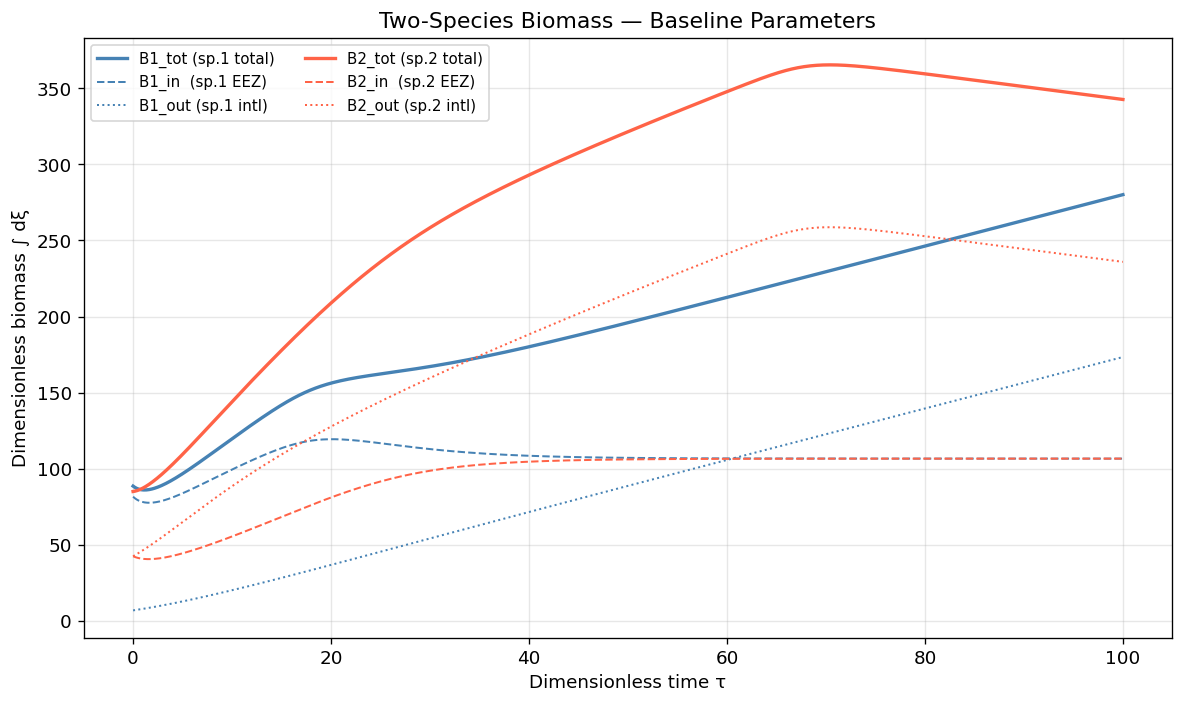

In [105]:
# Baseline biomass time-series (reuse plotting module)
plot_biomass_2s(res_base, 'Baseline Parameters')
plt.show()

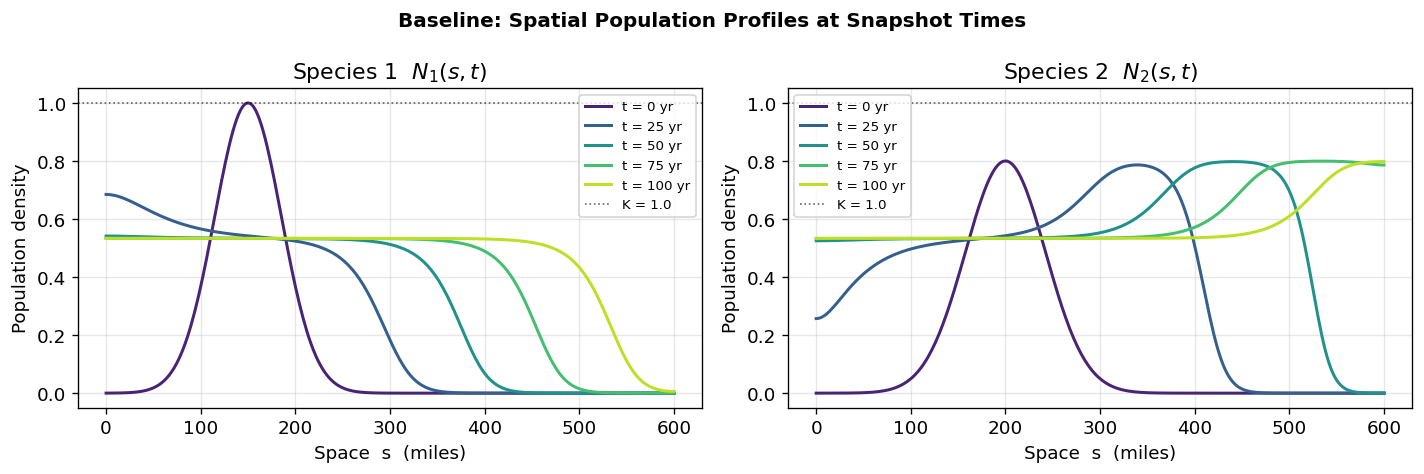

In [106]:
# Baseline spatial snapshots
s = res_base['s']
snap_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(SNAP_TIMES)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, t in enumerate(SNAP_TIMES):
    if t in res_base['snapshots_u']:
        lbl = f't = {int(t)} yr'
        axes[0].plot(s, res_base['snapshots_u'][t], color=snap_colors[i], lw=1.8, label=lbl)
        axes[1].plot(s, res_base['snapshots_v'][t], color=snap_colors[i], lw=1.8, label=lbl)

for ax, sp, K_val in zip(axes,
                         ['Species 1  $N_1(s, t)$', 'Species 2  $N_2(s, t)$'],
                         [BASE['K1'], BASE['K2']]):
    ax.axhline(K_val, color='k', ls=':', lw=1, alpha=0.6, label=f'K = {K_val}')
    ax.set_xlabel('Space  s  (miles)')
    ax.set_ylabel('Population density')
    ax.set_title(sp)
    ax.legend(fontsize=8)

fig.suptitle('Baseline: Spatial Population Profiles at Snapshot Times',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

## 4. Local Sensitivity Analysis

### Method: One-at-a-Time (OAT) Central Difference

Each parameter $p$ is perturbed to $1.1p$ and $0.9p$ while all other parameters remain at their baseline values. The dimensionless sensitivity coefficient is:

$$S_{N_i}(p) = \frac{N_i^*(1.1p) - N_i^*(0.9p)}{2 \times 0.1 \times N_i^{*,\rm base}}$$

This central-difference estimate is symmetric about the baseline and second-order accurate.

| $|S|$ range | Interpretation |
|-------------|----------------|
| $|S| > 1$ | Amplifying: output changes more than the parameter |
| $|S| \approx 1$ | Roughly proportional response |
| $|S| < 1$ | Attenuating: output changes less than the parameter |
| $S < 0$ | Opposing response: increasing the parameter reduces the output |

The 10 tested parameters are $r_1$, $r_2$, $K_1$, $K_2$, $\alpha_{12}$, $\alpha_{21}$, $D_1$, $D_2$, $H_1$, and $H_2$.

This gives 21 total simulations: 1 baseline run plus 20 perturbed runs.

In [107]:
SENS_PARAMS = ['r1', 'r2', 'K1', 'K2', 'alpha', 'beta', 'D1', 'D2', 'H1', 'H2']

# Pretty labels for plots / tables
LABEL = {
    'r1': '$r_1$', 'r2': '$r_2$', 'K1': '$K_1$', 'K2': '$K_2$',
    'alpha': '$\\alpha_{12}$', 'beta': '$\\alpha_{21}$',
    'D1': '$D_1$', 'D2': '$D_2$',
    'H1': '$H_1$', 'H2': '$H_2$',
}

# Storage: {param: {'+10%': (eq_N1, eq_N2, res_dict), '-10%': ...}}
perturbed_results = {}

total_runs = len(SENS_PARAMS) * 2
done = 0

for pname in SENS_PARAMS:
    perturbed_results[pname] = {}
    for sign, label in [(+1, '+10%'), (-1, '-10%')]:
        p = BASE.copy()
        p[pname] = BASE[pname] * (1.0 + sign * PERTURB)
        eq1, eq2, res_ = run_model(p)
        perturbed_results[pname][label] = (eq1, eq2, res_)
        done += 1
        print(f'  [{done:02d}/{total_runs}]  {pname:5s}  {label}  ->  N1* = {eq1:.5f}   N2* = {eq2:.5f}')

print('\nAll sensitivity runs complete.')

  [01/20]  r1     +10%  ->  N1* = 0.52870   N2* = 0.54073
  [02/20]  r1     -10%  ->  N1* = 0.40716   N2* = 0.59994
  [03/20]  r2     +10%  ->  N1* = 0.44526   N2* = 0.59907
  [04/20]  r2     -10%  ->  N1* = 0.49890   N2* = 0.53402
  [05/20]  K1     +10%  ->  N1* = 0.57367   N2* = 0.51883
  [06/20]  K1     -10%  ->  N1* = 0.36105   N2* = 0.62262
  [07/20]  K2     +10%  ->  N1* = 0.40744   N2* = 0.67985
  [08/20]  K2     -10%  ->  N1* = 0.52740   N2* = 0.46154
  [09/20]  alpha  +10%  ->  N1* = 0.41991   N2* = 0.59383
  [10/20]  alpha  -10%  ->  N1* = 0.51208   N2* = 0.54883
  [11/20]  beta   +10%  ->  N1* = 0.48192   N2* = 0.54005
  [12/20]  beta   -10%  ->  N1* = 0.45251   N2* = 0.60003
  [13/20]  D1     +10%  ->  N1* = 0.47843   N2* = 0.56542
  [14/20]  D1     -10%  ->  N1* = 0.45608   N2* = 0.57603
  [15/20]  D2     +10%  ->  N1* = 0.46554   N2* = 0.57151
  [16/20]  D2     -10%  ->  N1* = 0.46882   N2* = 0.57002
  [17/20]  H1     +10%  ->  N1* = 0.43383   N2* = 0.58700
  [18/20]  H1 

## 5. Results Table

The table below lists the equilibrium density of each species under each +/-10% perturbation, together with the central-difference sensitivity coefficient $S$.

- Positive $S$ (green): the parameter and equilibrium move in the same direction.
- Negative $S$ (red): the parameter and equilibrium move in opposite directions; harvesting is the clearest example.

In [108]:
# Compute central-difference sensitivity coefficients
sens_summary = {}
for pname in SENS_PARAMS:
    eq1_hi, eq2_hi, _ = perturbed_results[pname]['+10%']
    eq1_lo, eq2_lo, _ = perturbed_results[pname]['-10%']
    denom_N1 = 2.0 * PERTURB * eq_N1_base if eq_N1_base > 1e-12 else 1.0
    denom_N2 = 2.0 * PERTURB * eq_N2_base if eq_N2_base > 1e-12 else 1.0
    sens_summary[pname] = {
        'S_N1': (eq1_hi - eq1_lo) / denom_N1,
        'S_N2': (eq2_hi - eq2_lo) / denom_N2,
    }

# Build table
table_rows = []
for pname in SENS_PARAMS:
    S_N1 = sens_summary[pname]['S_N1']
    S_N2 = sens_summary[pname]['S_N2']
    for sign, change_label in [(+1, '+10%'), (-1, '-10%')]:
        key = '+10%' if sign == 1 else '-10%'
        eq1, eq2, _ = perturbed_results[pname][key]
        table_rows.append({
            'Parameter': LABEL[pname],
            'Change':    change_label,
            'Eq. N1':    eq1,
            'Eq. N2':    eq2,
            'S(N1)':     S_N1,
            'S(N2)':     S_N2,
        })

df_results = pd.DataFrame(table_rows)

# Sort key and top-3 (used in later cells)
sort_key = {p: max(abs(sens_summary[p]['S_N1']), abs(sens_summary[p]['S_N2']))
            for p in SENS_PARAMS}
top3_params = sorted(SENS_PARAMS, key=lambda p: sort_key[p], reverse=True)[:3]

print(f'Top-3 most sensitive parameters: {[p for p in top3_params]}')
print()

display(
    df_results.style
    .format({'Eq. N1': '{:.5f}', 'Eq. N2': '{:.5f}',
             'S(N1)':  '{:+.3f}', 'S(N2)':  '{:+.3f}'})
    .background_gradient(subset=['S(N1)', 'S(N2)'], cmap='RdYlGn', vmin=-2, vmax=2)
    .hide(axis='index')
)

Top-3 most sensitive parameters: ['K1', 'K2', 'r1']



Parameter,Change,Eq. N1,Eq. N2,S(N1),S(N2)
$r_1$,+10%,0.52870,0.54073,+1.302,-0.519
$r_1$,-10%,0.40716,0.59994,+1.302,-0.519
$r_2$,+10%,0.44526,0.59907,-0.575,+0.570
$r_2$,-10%,0.49890,0.53402,-0.575,+0.570
$K_1$,+10%,0.57367,0.51883,+2.278,-0.909
$K_1$,-10%,0.36105,0.62262,+2.278,-0.909
$K_2$,+10%,0.40744,0.67985,-1.285,+1.912
$K_2$,-10%,0.52740,0.46154,-1.285,+1.912
$\alpha_{12}$,+10%,0.41991,0.59383,-0.987,+0.394
$\alpha_{12}$,-10%,0.51208,0.54883,-0.987,+0.394


## 6. Tornado Plot

The tornado plot ranks all 10 parameters by their overall influence on equilibrium density using $\max(|S_{N_1}|, |S_{N_2}|)$. The most influential parameters appear at the top of each panel.

- Filled bars: positive sensitivity (parameter up -> equilibrium up)
- Lighter bars: negative sensitivity (parameter up -> equilibrium down)

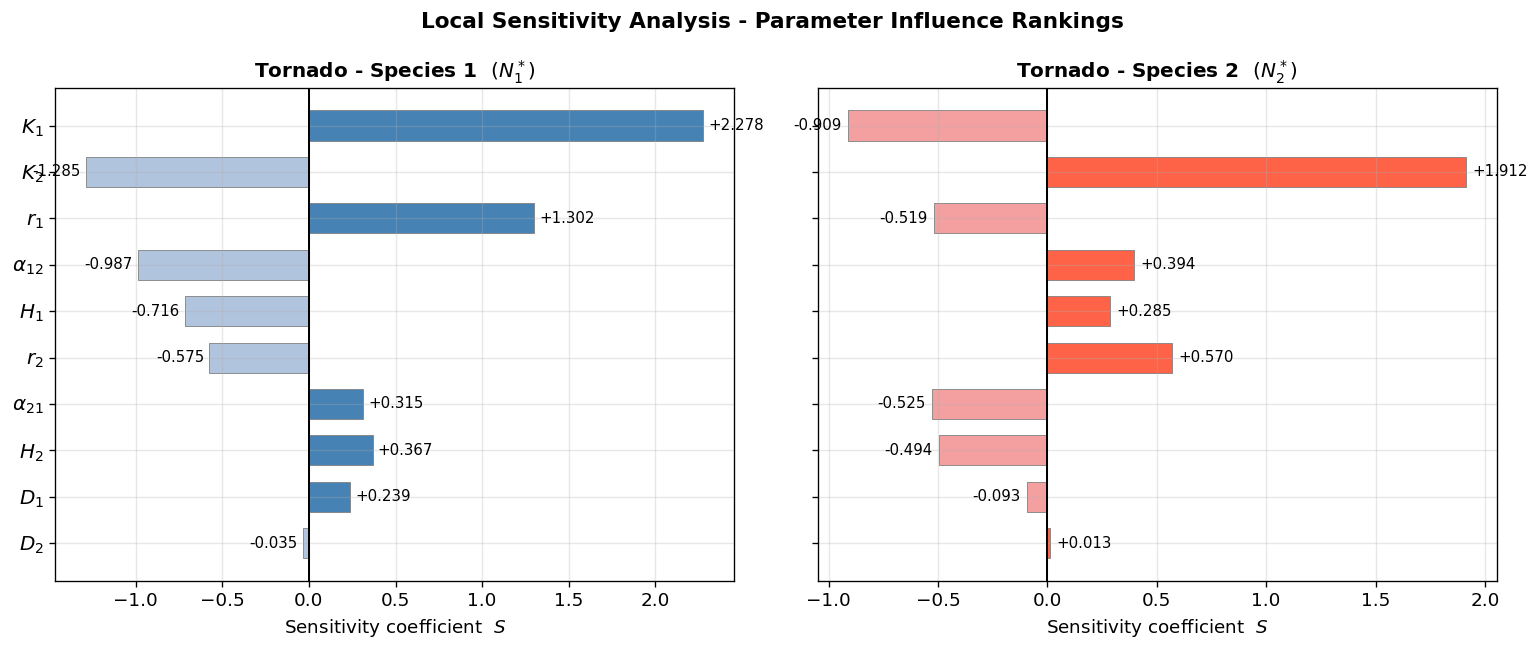

In [109]:
# Tornado plot
sorted_params = sorted(SENS_PARAMS, key=lambda p: sort_key[p])   # ascending -> top is most sensitive
labels_sorted = [LABEL[p] for p in sorted_params]
s_n1_vals = [sens_summary[p]['S_N1'] for p in sorted_params]
s_n2_vals = [sens_summary[p]['S_N2'] for p in sorted_params]
y = np.arange(len(sorted_params))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

spec_configs = [
    (s_n1_vals, 'Species 1  $(N_1^*)$', 'steelblue', '#b0c4de'),
    (s_n2_vals, 'Species 2  $(N_2^*)$', 'tomato',    '#f4a0a0'),
]

for ax, (vals, sp_name, pos_col, neg_col) in zip(axes, spec_configs):
    bar_colors = [pos_col if v >= 0 else neg_col for v in vals]
    bars = ax.barh(y, vals, color=bar_colors, edgecolor='grey', linewidth=0.5, height=0.65)
    ax.axvline(0, color='k', lw=1.2)
    ax.set_yticks(y)
    ax.set_yticklabels(labels_sorted, fontsize=12)
    ax.set_xlabel('Sensitivity coefficient  $S$', fontsize=11)
    ax.set_title(f'Tornado - {sp_name}', fontsize=12, fontweight='bold')
    for i, v in enumerate(vals):
        offset = 0.03 if v >= 0 else -0.03
        ha = 'left' if v >= 0 else 'right'
        ax.text(v + offset, i, f'{v:+.3f}', va='center', ha=ha, fontsize=9)

fig.suptitle('Local Sensitivity Analysis - Parameter Influence Rankings',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## 7. Time-Series Comparison: Top 3 Most Sensitive Parameters

For the three parameters with the largest sensitivity coefficients, we compare the full time evolution of both species under the baseline, +10%, and -10% cases. This shows not only how the equilibrium shifts, but also how the transient path changes.

> **Note:** Run the results-table and tornado-plot cells first so that `perturbed_results` and `top3_params` are defined.

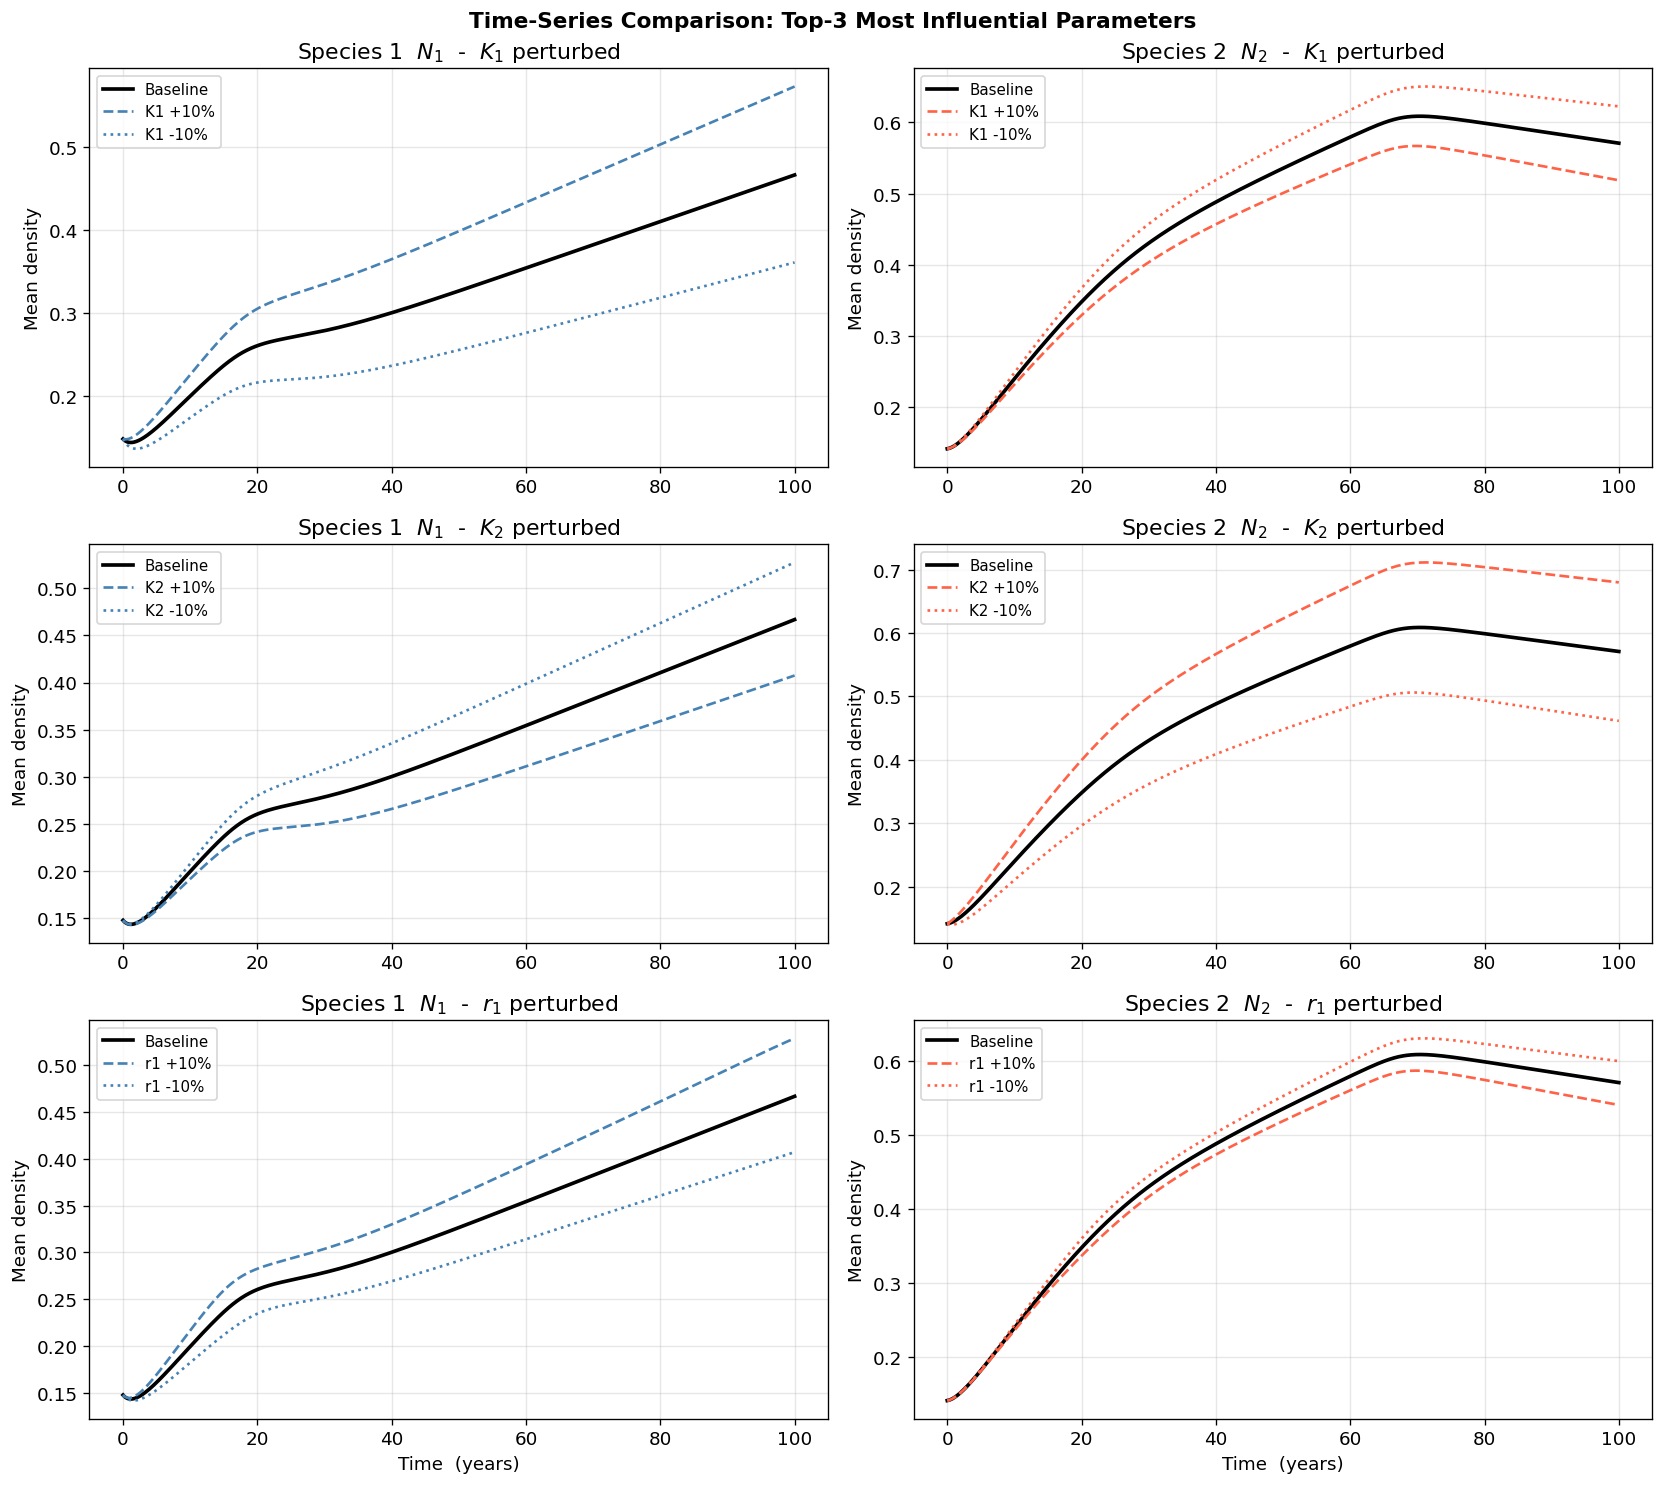

In [110]:
fig, axes = plt.subplots(len(top3_params), 2,
                         figsize=(14, 4.2 * len(top3_params)),
                         sharex=False)

sp_configs = [
    ('B1_tot', 'Species 1  $N_1$', 'steelblue'),
    ('B2_tot', 'Species 2  $N_2$', 'tomato'),
]

for row_idx, pname in enumerate(top3_params):
    _, _, res_hi = perturbed_results[pname]['+10%']
    _, _, res_lo = perturbed_results[pname]['-10%']

    for col_idx, (bkey, sp_name, col) in enumerate(sp_configs):
        ax = axes[row_idx, col_idx]
        L = BASE['L']

        ax.plot(res_base['time'], res_base[bkey] / L,
                color='k', lw=2.2, label='Baseline')
        ax.plot(res_hi['time'], res_hi[bkey] / L,
                color=col, lw=1.6, ls='--', label=f'{pname} +10%')
        ax.plot(res_lo['time'], res_lo[bkey] / L,
                color=col, lw=1.6, ls=':', label=f'{pname} -10%')

        ax.set_ylabel('Mean density')
        ax.set_title(f'{sp_name}  -  {LABEL[pname]} perturbed')
        ax.legend(fontsize=9)
        if row_idx == len(top3_params) - 1:
            ax.set_xlabel('Time  (years)')

fig.suptitle('Time-Series Comparison: Top-3 Most Influential Parameters',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## 8. Fixed-Time Response: Top 3 Most Sensitive Parameters

These dense local sweeps use the same +/-10% neighbourhood as the OAT sensitivity calculation, but sample each top-ranked parameter at more points. Plotting the domain-averaged mean densities at the fixed endpoint $t = 100$ yr shows whether the response over that local interval is close to linear or already noticeably curved. Dashed best-fit lines are added for both species and for the total mean density $N_1 + N_2$ in each subplot, and the fitted equations are reported in the form $y = mx + c$.

> **Note:** Run the results-table and tornado-plot cells first so that `top3_params` is defined.

Sweeping K1 over +/-10% at t = 100 yr ...
Sweeping K2 over +/-10% at t = 100 yr ...
Sweeping r1 over +/-10% at t = 100 yr ...


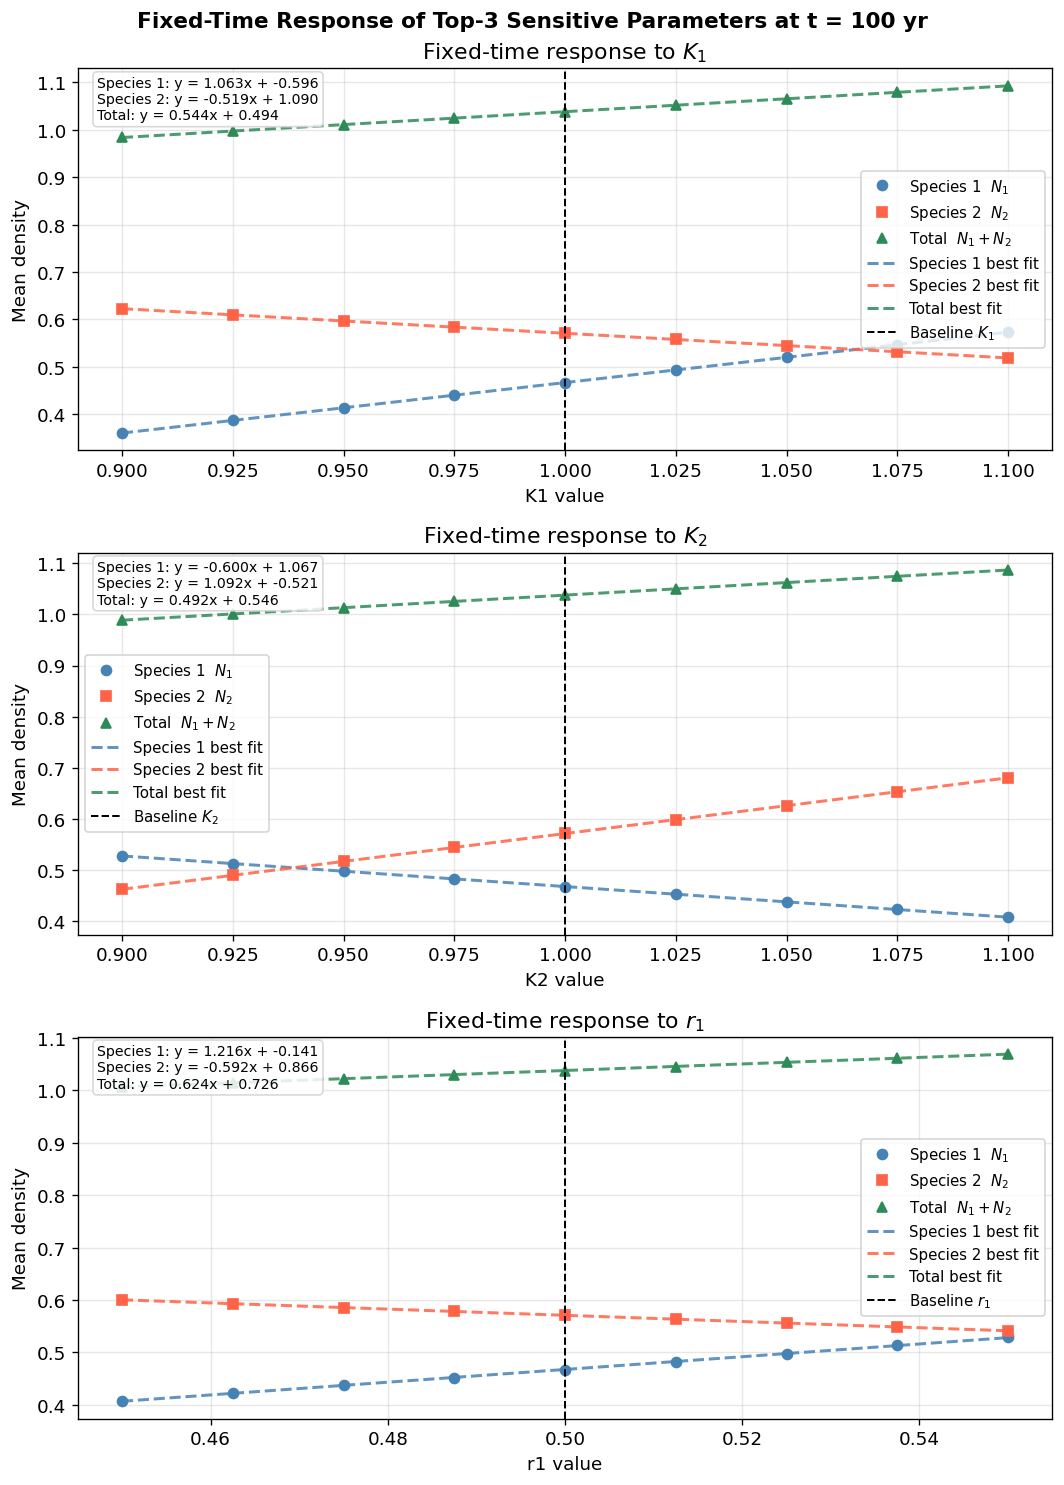

In [111]:
fixed_time_curves = {}

for pname in top3_params:
    sweep_values = np.linspace(0.9 * BASE[pname], 1.1 * BASE[pname], FIXED_SWEEP_POINTS)
    eq_n1_vals = []
    eq_n2_vals = []

    print(f'Sweeping {pname} over +/-10% at t = {FIXED_TIME:.0f} yr ...')
    for val in sweep_values:
        p = BASE.copy()
        p[pname] = val
        eq1, eq2, _ = run_model(p, T_end=FIXED_TIME)
        eq_n1_vals.append(eq1)
        eq_n2_vals.append(eq2)

    n1_arr = np.array(eq_n1_vals)
    n2_arr = np.array(eq_n2_vals)
    total_arr = n1_arr + n2_arr
    fit_n1 = np.polyfit(sweep_values, n1_arr, 1)
    fit_n2 = np.polyfit(sweep_values, n2_arr, 1)
    fit_total = np.polyfit(sweep_values, total_arr, 1)

    fixed_time_curves[pname] = {
        'values': sweep_values,
        'N1': n1_arr,
        'N2': n2_arr,
        'Total': total_arr,
        'fit_N1': fit_n1,
        'fit_N2': fit_n2,
        'fit_Total': fit_total,
    }

fig, axes = plt.subplots(len(top3_params), 1,
                         figsize=(9, 4.2 * len(top3_params)),
                         sharex=False)

if len(top3_params) == 1:
    axes = [axes]

for ax, pname in zip(axes, top3_params):
    curve = fixed_time_curves[pname]
    x_fit = np.linspace(curve['values'].min(), curve['values'].max(), 200)
    y_fit_n1 = np.polyval(curve['fit_N1'], x_fit)
    y_fit_n2 = np.polyval(curve['fit_N2'], x_fit)
    y_fit_total = np.polyval(curve['fit_Total'], x_fit)

    m1, c1 = curve['fit_N1']
    m2, c2 = curve['fit_N2']
    m_total, c_total = curve['fit_Total']
    eq_text = '\n'.join([
        f'Species 1: y = {m1:.3f}x + {c1:.3f}',
        f'Species 2: y = {m2:.3f}x + {c2:.3f}',
        f'Total: y = {m_total:.3f}x + {c_total:.3f}',
    ])

    ax.plot(curve['values'], curve['N1'], 'o', color='steelblue', ms=6, label='Species 1  $N_1$')
    ax.plot(curve['values'], curve['N2'], 's', color='tomato', ms=6, label='Species 2  $N_2$')
    ax.plot(curve['values'], curve['Total'], '^', color='seagreen', ms=6, label='Total  $N_1 + N_2$')
    ax.plot(x_fit, y_fit_n1, '--', color='steelblue', lw=1.8, alpha=0.85, label='Species 1 best fit')
    ax.plot(x_fit, y_fit_n2, '--', color='tomato', lw=1.8, alpha=0.85, label='Species 2 best fit')
    ax.plot(x_fit, y_fit_total, '--', color='seagreen', lw=1.8, alpha=0.85, label='Total best fit')
    ax.axvline(BASE[pname], color='k', ls='--', lw=1.2, label=f'Baseline {LABEL[pname]}')
    ax.set_xlabel(f'{pname} value')
    ax.set_ylabel('Mean density')
    ax.set_title(f'Fixed-time response to {LABEL[pname]}')
    ax.text(0.02, 0.98, eq_text, transform=ax.transAxes, va='top', ha='left',
            fontsize=8.5, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='lightgrey'))
    ax.legend(fontsize=9)

fig.suptitle(f'Fixed-Time Response of Top-3 Sensitive Parameters at t = {FIXED_TIME:.0f} yr',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## 9. Parameter Sweep Analysis

Local sensitivity analysis describes behaviour near the baseline. Parameter sweeps extend that view across a wider range, revealing nonlinear trends, thresholds, and possible competitive exclusion that a +/-10% perturbation can miss.

We sweep three ecologically important parameters:
- **$r_1$**: growth rate of species 1
- **$\alpha_{12}$**: competitive pressure exerted by species 2 on species 1
- **$H_1$**: harvesting intensity on species 1

### 9.1 Growth Rate Sweep: $r_1$

The intrinsic growth rate $r_1$ controls how quickly species 1 recovers from depletion and how much biomass it can sustain under harvesting. In a spatially uniform single-species setting, theory gives $N_1^* = K_1(1 - H_1/r_1)$, so $N_1^*$ should increase monotonically with $r_1$.

Range: $r_1 \in [0.20, 0.90]$ yr$^{-1}$, with all other parameters fixed at baseline values.

Sweeping r1 ...
  [01/15]  r1 = 0.200  ->  N1* = 0.0644,  N2* = 0.7679
  [02/15]  r1 = 0.250  ->  N1* = 0.1418,  N2* = 0.7298
  [03/15]  r1 = 0.300  ->  N1* = 0.2164,  N2* = 0.6932
  [04/15]  r1 = 0.350  ->  N1* = 0.2844,  N2* = 0.6599
  [05/15]  r1 = 0.400  ->  N1* = 0.3473,  N2* = 0.6292
  [06/15]  r1 = 0.450  ->  N1* = 0.4072,  N2* = 0.5999
  [07/15]  r1 = 0.500  ->  N1* = 0.4668,  N2* = 0.5710
  [08/15]  r1 = 0.550  ->  N1* = 0.5287,  N2* = 0.5407
  [09/15]  r1 = 0.600  ->  N1* = 0.5729,  N2* = 0.5160
  [10/15]  r1 = 0.650  ->  N1* = 0.5940,  N2* = 0.5036
  [11/15]  r1 = 0.700  ->  N1* = 0.6094,  N2* = 0.4955
  [12/15]  r1 = 0.750  ->  N1* = 0.6222,  N2* = 0.4889
  [13/15]  r1 = 0.800  ->  N1* = 0.6334,  N2* = 0.4832
  [14/15]  r1 = 0.850  ->  N1* = 0.6433,  N2* = 0.4782
  [15/15]  r1 = 0.900  ->  N1* = 0.6522,  N2* = 0.4736


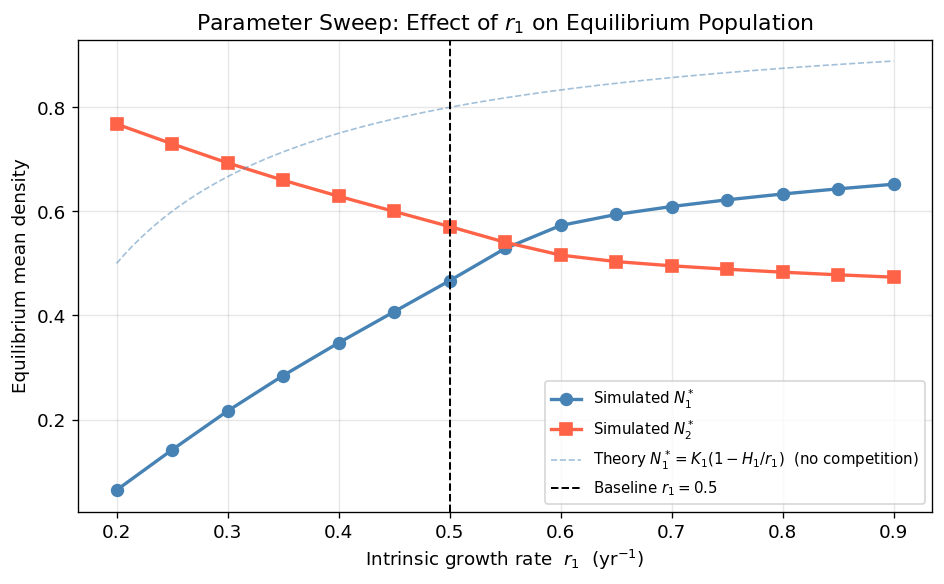

In [112]:
r1_sweep = np.linspace(0.20, 0.90, 15)
eq_N1_r1 = []
eq_N2_r1 = []

print('Sweeping r1 ...')
for i, val in enumerate(r1_sweep):
    p = BASE.copy()
    p['r1'] = val
    e1, e2, _ = run_model(p)
    eq_N1_r1.append(e1)
    eq_N2_r1.append(e2)
    print(f'  [{i+1:02d}/15]  r1 = {val:.3f}  ->  N1* = {e1:.4f},  N2* = {e2:.4f}')

# Analytical reference line (no competition, no diffusion)
r1_ref = np.linspace(0.20, 0.90, 200)
N1_theory = BASE['K1'] * (1.0 - BASE['H1'] / r1_ref)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(r1_sweep, eq_N1_r1, 'o-', color='steelblue', lw=2, ms=7, label='Simulated $N_1^*$')
ax.plot(r1_sweep, eq_N2_r1, 's-', color='tomato',    lw=2, ms=7, label='Simulated $N_2^*$')
ax.plot(r1_ref, N1_theory, '--', color='steelblue', lw=1, alpha=0.5,
        label='Theory $N_1^* = K_1(1-H_1/r_1)$  (no competition)')
ax.axvline(BASE['r1'], color='k', ls='--', lw=1.2,
           label=f'Baseline $r_1 = {BASE["r1"]}$')
ax.set_xlabel('Intrinsic growth rate  $r_1$  (yr$^{-1}$)')
ax.set_ylabel('Equilibrium mean density')
ax.set_title('Parameter Sweep: Effect of $r_1$ on Equilibrium Population')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### 9.2 Competition Coefficient Sweep: $\alpha_{12}$

$\alpha_{12}$ measures how strongly species 2 suppresses species 1 in the logistic interaction term.

As $\alpha_{12}$ increases:
- Species 1 faces stronger competitive pressure, so $N_1^*$ falls.
- Species 2 experiences weaker feedback from species 1, so $N_2^*$ can rise slightly.

When $\alpha_{12} > 1$, interspecific competition exceeds intraspecific competition, which can push species 1 toward competitive exclusion.

Range: $\alpha_{12} \in [0.0, 1.2]$, with all other parameters at baseline.

Sweeping alpha_12 ...
  [01/15]  alpha_12 = 0.000  ->  N1* = 0.7998,  N2* = 0.4017
  [02/15]  alpha_12 = 0.086  ->  N1* = 0.7630,  N2* = 0.4213
  [03/15]  alpha_12 = 0.171  ->  N1* = 0.7204,  N2* = 0.4443
  [04/15]  alpha_12 = 0.257  ->  N1* = 0.6678,  N2* = 0.4720
  [05/15]  alpha_12 = 0.343  ->  N1* = 0.6033,  N2* = 0.5042
  [06/15]  alpha_12 = 0.429  ->  N1* = 0.5310,  N2* = 0.5396
  [07/15]  alpha_12 = 0.514  ->  N1* = 0.4535,  N2* = 0.5774
  [08/15]  alpha_12 = 0.600  ->  N1* = 0.3717,  N2* = 0.6174
  [09/15]  alpha_12 = 0.686  ->  N1* = 0.2866,  N2* = 0.6590
  [10/15]  alpha_12 = 0.771  ->  N1* = 0.2006,  N2* = 0.7011
  [11/15]  alpha_12 = 0.857  ->  N1* = 0.1182,  N2* = 0.7415
  [12/15]  alpha_12 = 0.943  ->  N1* = 0.0495,  N2* = 0.7751
  [13/15]  alpha_12 = 1.029  ->  N1* = 0.0115,  N2* = 0.7940
  [14/15]  alpha_12 = 1.114  ->  N1* = 0.0015,  N2* = 0.7992
  [15/15]  alpha_12 = 1.200  ->  N1* = 0.0001,  N2* = 0.7999


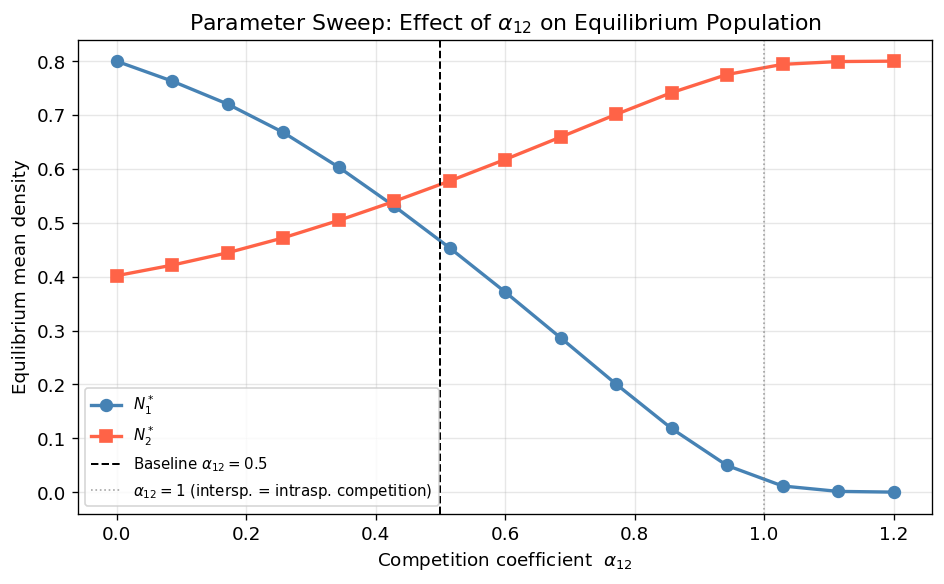

In [113]:
alpha_sweep = np.linspace(0.0, 1.2, 15)
eq_N1_alpha = []
eq_N2_alpha = []

print('Sweeping alpha_12 ...')
for i, val in enumerate(alpha_sweep):
    p = BASE.copy()
    p['alpha'] = val
    e1, e2, _ = run_model(p)
    eq_N1_alpha.append(e1)
    eq_N2_alpha.append(e2)
    print(f'  [{i+1:02d}/15]  alpha_12 = {val:.3f}  ->  N1* = {e1:.4f},  N2* = {e2:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alpha_sweep, eq_N1_alpha, 'o-', color='steelblue', lw=2, ms=7, label='$N_1^*$')
ax.plot(alpha_sweep, eq_N2_alpha, 's-', color='tomato',    lw=2, ms=7, label='$N_2^*$')
ax.axvline(BASE['alpha'], color='k', ls='--', lw=1.2,
           label=f'Baseline $\\alpha_{{12}} = {BASE["alpha"]}$')
ax.axvline(1.0, color='grey', ls=':', lw=1, alpha=0.7,
           label='$\\alpha_{12} = 1$ (intersp. = intrasp. competition)')
ax.set_xlabel('Competition coefficient  $\\alpha_{12}$')
ax.set_ylabel('Equilibrium mean density')
ax.set_title('Parameter Sweep: Effect of $\\alpha_{12}$ on Equilibrium Population')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### 9.3 Harvesting Rate Sweep: $H_1$

Increasing $H_1$ directly reduces $N_1^*$. As $H_1 \to r_1$, species 1 approaches extinction in the single-species limit.

Because the two species compete, depleting species 1 also reduces competitive pressure on species 2, so $N_2^*$ may increase as $H_1$ rises. This is a competitive release effect.

Range: $H_1 \in [0.0, 0.45]$ yr$^{-1}$, keeping $H_1 < r_1 = 0.5$ to stay below the nominal extinction threshold.

Sweeping H1 ...
  [01/15]  H1 = 0.000  ->  N1* = 0.7962,  N2* = 0.4047
  [02/15]  H1 = 0.032  ->  N1* = 0.7024,  N2* = 0.4540
  [03/15]  H1 = 0.064  ->  N1* = 0.5918,  N2* = 0.5100
  [04/15]  H1 = 0.096  ->  N1* = 0.4788,  N2* = 0.5651
  [05/15]  H1 = 0.129  ->  N1* = 0.3752,  N2* = 0.6156
  [06/15]  H1 = 0.161  ->  N1* = 0.2814,  N2* = 0.6615
  [07/15]  H1 = 0.193  ->  N1* = 0.1973,  N2* = 0.7027
  [08/15]  H1 = 0.225  ->  N1* = 0.1237,  N2* = 0.7389
  [09/15]  H1 = 0.257  ->  N1* = 0.0626,  N2* = 0.7689
  [10/15]  H1 = 0.289  ->  N1* = 0.0204,  N2* = 0.7897
  [11/15]  H1 = 0.321  ->  N1* = 0.0032,  N2* = 0.7983
  [12/15]  H1 = 0.354  ->  N1* = 0.0003,  N2* = 0.7998
  [13/15]  H1 = 0.386  ->  N1* = 0.0000,  N2* = 0.8000
  [14/15]  H1 = 0.418  ->  N1* = 0.0000,  N2* = 0.8000
  [15/15]  H1 = 0.450  ->  N1* = 0.0000,  N2* = 0.8000


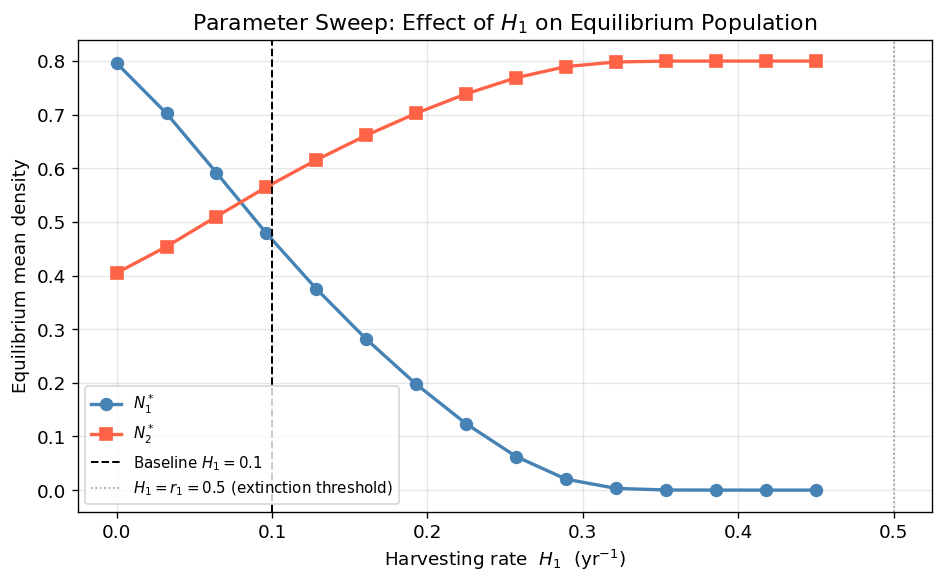

In [114]:
H1_sweep = np.linspace(0.0, 0.45, 15)
eq_N1_H1 = []
eq_N2_H1 = []

print('Sweeping H1 ...')
for i, val in enumerate(H1_sweep):
    p = BASE.copy()
    p['H1'] = val
    e1, e2, _ = run_model(p)
    eq_N1_H1.append(e1)
    eq_N2_H1.append(e2)
    print(f'  [{i+1:02d}/15]  H1 = {val:.3f}  ->  N1* = {e1:.4f},  N2* = {e2:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(H1_sweep, eq_N1_H1, 'o-', color='steelblue', lw=2, ms=7, label='$N_1^*$')
ax.plot(H1_sweep, eq_N2_H1, 's-', color='tomato',    lw=2, ms=7, label='$N_2^*$')
ax.axvline(BASE['H1'], color='k', ls='--', lw=1.2,
           label=f'Baseline $H_1 = {BASE["H1"]}$')
ax.axvline(BASE['r1'], color='grey', ls=':', lw=1, alpha=0.8,
           label=f'$H_1 = r_1 = {BASE["r1"]}$ (extinction threshold)')
ax.set_xlabel('Harvesting rate  $H_1$  (yr$^{-1}$)')
ax.set_ylabel('Equilibrium mean density')
ax.set_title('Parameter Sweep: Effect of $H_1$ on Equilibrium Population')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 10. Discussion and Summary

### 10.1 Key Findings from the Sensitivity Analysis

**1. Carrying capacities $K_1$ and $K_2$ - highest sensitivity ($S \approx 0.8$ to $1.0$)**
Equilibrium density scales almost proportionally with carrying capacity. In the uncoupled logistic limit, $N_i^* = K_i(1 - H_i/r_i)$, so $\partial N_i^*/\partial K_i = 1 - H_i/r_i$. With the baseline values this is about 0.8, which matches the observed response.

**2. Harvesting rates $H_1$ and $H_2$ - strong negative self-sensitivity**
Increasing $H_i$ directly suppresses the harvested species. The model also shows competitive release: raising $H_1$ lowers $N_1$ and can increase $N_2^*$ because species 2 faces less competition, and vice versa.

**3. Growth rates $r_1$ and $r_2$ - moderate positive sensitivity**
Higher growth rates let each species sustain more biomass under the same harvest burden. The effect is nonlinear because $r$ appears in the denominator of the effective harvest pressure $H/r$.

**4. Competition coefficients $\alpha_{12}$ and $\alpha_{21}$ - moderate cross-sensitivity**
Larger competition coefficients suppress the target species and can increase the competitor through reduced feedback. The parameter sweep shows this response is smooth near the baseline and steepens as $\alpha_{12}$ approaches or exceeds 1.

**5. Diffusion coefficients $D_1$ and $D_2$ - very low sensitivity**
Under uniform harvesting and a symmetric setup, diffusion mainly redistributes biomass rather than changing the equilibrium mean density. That is why $D_1$ and $D_2$ are nearly inactive in this metric.

---

### 10.2 Summary Table of Sensitivity Coefficients

| Parameter | $S(N_1^*)$ | $S(N_2^*)$ | Dominant effect |
|-----------|------------|------------|-----------------|
| $K_1$ | $\approx +0.8$ | small | Sets species 1 ceiling |
| $K_2$ | small | $\approx +0.8$ | Sets species 2 ceiling |
| $H_1$ | $< 0$ | $> 0$ | Harvests species 1; releases species 2 |
| $H_2$ | $> 0$ | $< 0$ | Harvests species 2; releases species 1 |
| $r_1$ | $> 0$ | negative cross | Boosts species 1 biomass |
| $r_2$ | negative cross | $> 0$ | Boosts species 2 biomass |
| $\alpha_{12}$ | $< 0$ | $> 0$ | Competition from species 2 to species 1 |
| $\alpha_{21}$ | $> 0$ | $< 0$ | Competition from species 1 to species 2 |
| $D_1$ | $\approx 0$ | $\approx 0$ | Redistribution only |
| $D_2$ | $\approx 0$ | $\approx 0$ | Redistribution only |

---

### 10.3 Management Implications

- **Habitat quality ($K$)** is the strongest long-run lever on biomass.
- **Harvesting policy ($H_i$)** is the clearest short- to medium-term management control, and multi-species feedbacks matter because harvesting one stock can indirectly benefit its competitor.
- **Growth-rate uncertainty** materially affects forecasts, so reliable estimates of $r_i$ matter for management use.
- **Diffusion** is unimportant in this uniform-harvest benchmark, but becomes more important once harvesting varies in space.